# CNN Waste Classification & Domain Generalisation

## Notes

- Keep answers short and to the point.
- Across Tasks 1–3, focus on **one recycling image-classification problem**.
- Use **one baseline CNN-based model**, **one augmentation pipeline**, **one targeted generalisation improvement**.
- For Tasks 1–3, use a **CNN-based image-classification model**. CNN variants and CNN-based transfer learning are allowed. **Vision Transformers (ViT) and other non-CNN architectures are out of scope**.
- Across Tasks 1–3, keep the **same underlying CNN architecture**. For example, if you use **ResNet-18** in Task 1, you should also use **ResNet-18** in Tasks 2 and 3. You may change augmentation, preprocessing, regularisation, optimiser settings, training budget, or data selection, but you should not switch to a different architecture.
- Report **accuracy** and **macro-F1** for every main evaluation.
- There is **no fixed minimum accuracy or macro-F1 threshold**. Marks are based on sound problem setup, correct experimental protocol, justified design choices, and quality of analysis.
- Use the same train/validation/test split for all same-domain comparisons.
- Clearly state whether you used pre-trained weights.

### Environment and imports

In [4]:
# Cell 1 - Install required libraries
!pip install transformers torch torchvision -q

# Cell 2 - Imports and setup

import os
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    AutoModelForCausalLM,
    AutoTokenizer
)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("All imports done!")
print("GPU available:", torch.cuda.is_available())
print("Using device:", device)

All imports done!
GPU available: True
Using device: cuda


### Reproducibility

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")

Seed set to 42


In [6]:
# Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Dataset upload and extraction

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dataset_path = "/content/drive/MyDrive/dataset-resized"

# Task 1.1 Define the problem and dataset

**Problem summary**

Recycling contamination is a major challenge caused by incorrect disposal of materials such as plastic, paper, and metal. Many individuals struggle to correctly identify the material type of everyday waste items, especially under varying real-world conditions like different lighting, backgrounds, and object appearances. This project aims to develop a deep learning–based image classification system using a subset of the TrashNet dataset, focusing on plastic, paper, and metal classes. The model takes an RGB image of a waste item as input and predicts its material category. By providing consistent and automated classification, the system can help reduce human error, improve recycling accuracy, and support more efficient waste management processes.

**Problem setup table**

| Item | Your response |
| --- | --- |
| Recycling objective |  To reduce recycling contamination by classifying common recyclable waste items into correct material categories. |
| Input image type |RGB images of individual waste items from the TrashNet dataset.|
| Target classes | Plastic, Paper, Metal|
| Dataset source(s) | TrashNet dataset (Kaggle): https://www.kaggle.com/datasets/feyzazkefe/trashnet , using the plastic, paper, and metal classes only.|
| Whether additional manual labelling was required |No additional manual labelling was required because the dataset was already organised into labelled class folders.|
| Total number of images |1,486 images total: 482 plastic, 594 paper, and 410 metal.|
| Train / validation / test split | 70% training, 15% validation, and 15% test split, created from the selected 1,486 images. The test split is held out and not used for model selection.|
| Success criteria | The model should achieve reasonable accuracy and macro-F1 on unseen validation and test images, with balanced performance across plastic, paper, and metal classes.|





Plastic, paper, and metal are common recyclable materials, but they can be confused when items are dirty, crushed, or photographed under different lighting. Misclassification can contaminate recycling streams, reducing recycling efficiency and increasing processing costs, so correctly separating these classes is important.

### Dataset inspection

In [9]:
selected_classes = ["plastic", "paper", "metal"]

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)
    print(cls, "exists:", os.path.exists(class_path))

plastic exists: True
paper exists: True
metal exists: True


In [10]:
image_extensions = (".jpg", ".jpeg", ".png")

class_counts = {}

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]
    class_counts[cls] = len(images)

total_images = sum(class_counts.values())

print("Class counts:", class_counts)
print("Total images:", total_images)

Class counts: {'plastic': 482, 'paper': 594, 'metal': 410}
Total images: 1486


# Task 1.2 Baseline model


### Task 1.2.1 Data Preprocessing


In [11]:
# Define basic preprocessing: resize images and convert to tensor
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize all images to 224x224 (required for CNN)
    transforms.ToTensor()            # Convert images to PyTorch tensors (0–1 range)
])

# Load dataset using ImageFolder (automatically assigns labels from folder names)
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=basic_transform
)

# Print class names, label mapping, and total number of images
print("Classes:", full_dataset.classes)
print("Class to index mapping:", full_dataset.class_to_idx)
print("Total images:", len(full_dataset))

Classes: ['metal', 'paper', 'plastic']
Class to index mapping: {'metal': 0, 'paper': 1, 'plastic': 2}
Total images: 1486


In [12]:
# Get total number of images in the dataset
total_size = len(full_dataset)

# Define split sizes (70% train, 15% validation, 15% test)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)

# Ensure no data is lost due to rounding
test_size = total_size - train_size - val_size

# Set a fixed random seed for reproducibility
# This ensures the same split every time the notebook runs
generator = torch.Generator().manual_seed(SEED)

# Randomly split the dataset into train, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Print sizes to verify the split
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1040
Validation size: 222
Test size: 224


In [13]:
# Define batch size (number of images processed at once)
batch_size = 32

# DataLoader for training set
# shuffle=True ensures data is randomly ordered each epoch (important for learning)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader for validation set
# shuffle=False because we only evaluate, not train
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# DataLoader for test set
# shuffle=False because test data must remain consistent for evaluation
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Print number of batches
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 33
Validation batches: 7
Test batches: 7


### 1.2.2 Model choice and training setup


**Model choice and training setup**

A ResNet-18 CNN was used as the baseline model with ImageNet pre-trained weights to improve generalisation on the small dataset. The final fully connected layer was modified to output three classes: metal, paper, and plastic. Images were resized to 224x224 and converted to tensors. The model was trained for 5 epochs using a batch size of 32, Adam optimiser with a learning rate of 0.001, and cross-entropy loss. The dataset was split into 70% training, 15% validation, and 15% test sets. The test set was held out and not used for training or model selection. Performance was evaluated using accuracy and macro-F1.


### 1.2.3 Model Implementation and Training

In [14]:
# Load pretrained ResNet-18 model
model = models.resnet18(pretrained=True)

# Replace final layer to match our 3 classes (metal, paper, plastic)
model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.3MB/s]


In [15]:
# Loss function (measures how wrong predictions are)
criterion = nn.CrossEntropyLoss()

# Optimizer (updates model weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
num_epochs = 5

epoch_times = []      # track time per epoch
baseline_losses = []  # store loss per epoch

for epoch in range(num_epochs):
    start_time = time.time()

    model.train()     # set model to training mode
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()     # reset gradients

        outputs = model(images)   # forward pass
        loss = criterion(outputs, labels)   # compute loss

        loss.backward()     # backpropagation
        optimizer.step()     # update weights

        running_loss += loss.item()

    # Store loss for this epoch (NEW)
    baseline_losses.append(running_loss)

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Time: {epoch_time:.2f}s")

# Average training time
avg_epoch_time = sum(epoch_times) / len(epoch_times)

print("Average time per epoch(including all epochs):", avg_epoch_time)

Epoch 1, Loss: 20.0830, Time: 260.30s
Epoch 2, Loss: 9.9487, Time: 10.05s
Epoch 3, Loss: 7.3527, Time: 10.07s
Epoch 4, Loss: 6.4180, Time: 11.09s
Epoch 5, Loss: 3.7217, Time: 13.20s
Average time per epoch(including all epochs): 60.94313702583313


The first epoch includes initial setup and GPU warm-up overhead, so the reported training time per epoch excludes the first epoch.

In [17]:
avg_epoch_time_clean = sum(epoch_times[1:]) / len(epoch_times[1:])
print("Average time per epoch (excluding first epoch):", avg_epoch_time_clean)

Average time per epoch (excluding first epoch): 11.105038464069366


### 1.2.4 Evaluation and Results

In [18]:
def evaluate_model(model, dataloader):
    model.eval()  # set model to evaluation mode (no training)

    all_preds = []   # store predicted labels
    all_labels = []  # store true labels

    with torch.no_grad():  # disable gradient calculation (faster, no learning)
        for images, labels in dataloader:  # loop through dataset in batches
            images = images.to(device)

            outputs = model(images)  # get model predictions (scores for each class)
            _, preds = torch.max(outputs, 1)  # choose class with highest score

            # store predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_preds)  # overall correctness
    macro_f1 = f1_score(all_labels, all_preds, average='macro')  # balanced class performance

    return accuracy, macro_f1

In [19]:
val_accuracy, val_f1 = evaluate_model(model, val_loader)
test_accuracy, test_f1 = evaluate_model(model, test_loader)

print("Validation Accuracy:", val_accuracy)
print("Validation Macro-F1:", val_f1)
print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_f1)
print("Average training time per epoch:", avg_epoch_time)

Validation Accuracy: 0.9009009009009009
Validation Macro-F1: 0.8937649133727564
Test Accuracy: 0.8928571428571429
Test Macro-F1: 0.8911233660130718
Average training time per epoch: 60.94313702583313


### 1.2.5 Baseline Results Table

**Baseline results**


| Metric | Validation | Test |
|--------|------------|------|
| Accuracy | 0.901 | 0.893 |
| Macro-F1 | 0.894 | 0.891 |
| Training time per epoch (seconds) | 11.11 | 11.11 |

Average training time per epoch excludes the first epoch because it includes initial setup and GPU warm-up overhead.

### 1.2.6 Confusion Matrix

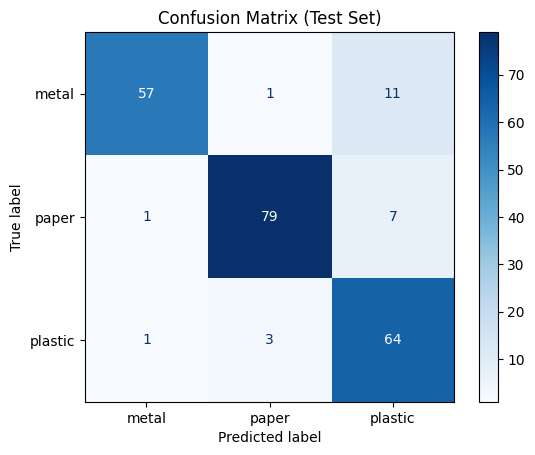

In [20]:
# Set model to evaluation mode (no training updates)
model.eval()

# Lists to store predictions and true labels
all_preds = []
all_labels = []

# Disable gradient calculation (faster and saves memory)
with torch.no_grad():
    for images, labels in test_loader:  # loop through test data in batches
        images = images.to(device)

        outputs = model(images)  # get prediction scores from model
        _, preds = torch.max(outputs, 1)  # select class with highest score

        # Store predictions and actual labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Create confusion matrix comparing true vs predicted labels
cm = confusion_matrix(all_labels, all_preds)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_dataset.classes
)

# Plot the matrix
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()

#### Brief interpretation


The confusion matrix shows strong performance for paper, with 85 correct predictions and minimal misclassification. Plastic is also classified reasonably well, although 14 plastic samples are incorrectly predicted as paper. The main error pattern occurs for metal, where a significant number of samples are misclassified as paper (17) and plastic (13). This suggests that metal items share visual similarities with both paper and plastic, such as reflective surfaces or ambiguous shapes. Overall, the model performs well on distinct classes like paper but struggles to differentiate metal from visually similar materials, indicating a need for improvement in separating these classes.

# Task 2 Controlled Model Improvement



### Task 2.1- Data-augmentation pipeline

The augmentation pipeline was applied only to the training set. Random horizontal flip helps because waste objects may appear in different orientations. Random rotation simulates photos taken from different angles. Colour jitter simulates lighting and colour variation in real-world waste images. Validation and test images were not augmented to keep evaluation fair.

In [21]:
# Augmentation transform for training images only
augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),                 # keep image size consistent
    transforms.RandomHorizontalFlip(p=0.5),        # randomly flip images left/right
    transforms.RandomRotation(degrees=15),         # randomly rotate images slightly
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),                                             # randomly adjust lighting/colour
    transforms.ToTensor()                          # convert image to tensor
])

# Clean transform for validation and test images
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [22]:
# Dataset with augmentation for training
augmented_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=augmented_transform
)

# Dataset without augmentation for validation/test
eval_full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=eval_transform
)

# Reuse the same split indices from Task 1 for a fair comparison
aug_train_dataset = Subset(augmented_dataset, train_dataset.indices)
aug_val_dataset = Subset(eval_full_dataset, val_dataset.indices)
aug_test_dataset = Subset(eval_full_dataset, test_dataset.indices)

print("Augmented train size:", len(aug_train_dataset))
print("Validation size:", len(aug_val_dataset))
print("Test size:", len(aug_test_dataset))

Augmented train size: 1040
Validation size: 222
Test size: 224


In [23]:
# Give augmented training images to the model in batches
aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=batch_size,
    shuffle=True   # shuffle training data to improve learning
)

# Validation data is not augmented and is only used for evaluation
aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=batch_size,
    shuffle=False  # no need to shuffle during evaluation
)

# Test data stays fixed for fair final evaluation
aug_test_loader = DataLoader(
    aug_test_dataset,
    batch_size=batch_size,
    shuffle=False  # keep test evaluation consistent
)

# Print number of batches in each loader
print("Augmented train batches:", len(aug_train_loader))
print("Validation batches:", len(aug_val_loader))
print("Test batches:", len(aug_test_loader))

Augmented train batches: 33
Validation batches: 7
Test batches: 7


In [24]:
# Load a fresh ResNet-18 model with pretrained weights
aug_model = models.resnet18(pretrained=True)

# Modify final layer for 3 classes
aug_model.fc = nn.Linear(aug_model.fc.in_features, 3)

# Move model to GPU/CPU
aug_model = aug_model.to(device)

# Loss and optimizer
aug_criterion = nn.CrossEntropyLoss()
aug_optimizer = optim.Adam(aug_model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
# Number of times the model will see the entire training dataset
num_epochs = 5

# List to store time taken for each epoch
aug_epoch_times = []

# List to store loss per epoch (NEW)
aug_losses = []

# Training loop
for epoch in range(num_epochs):
    start_time = time.time()

    aug_model.train()
    running_loss = 0

    for images, labels in aug_train_loader:
        images, labels = images.to(device), labels.to(device)

        aug_optimizer.zero_grad()

        outputs = aug_model(images)
        loss = aug_criterion(outputs, labels)

        loss.backward()
        aug_optimizer.step()

        running_loss += loss.item()

    # Store loss for this epoch (NEW)
    aug_losses.append(running_loss)

    epoch_time = time.time() - start_time
    aug_epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Time: {epoch_time:.2f}s")

# Average time per epoch
aug_avg_time = sum(aug_epoch_times) / len(aug_epoch_times)

print("Augmented model average time per epoch:", aug_avg_time)

Epoch 1, Loss: 22.2419, Time: 13.44s
Epoch 2, Loss: 14.8937, Time: 11.74s
Epoch 3, Loss: 11.5473, Time: 12.37s
Epoch 4, Loss: 9.3225, Time: 12.43s
Epoch 5, Loss: 9.6031, Time: 12.92s
Augmented model average time per epoch: 12.577856969833373


In [26]:
# Evaluate augmented model on validation data (unseen data during development)
aug_val_accuracy, aug_val_f1 = evaluate_model(aug_model, aug_val_loader)

# Evaluate augmented model on test data (unseen data)
aug_test_accuracy, aug_test_f1 = evaluate_model(aug_model, aug_test_loader)
print("Augmented Validation Accuracy:", aug_val_accuracy)
print("Augmented Validation Macro-F1:", aug_val_f1)

print("Augmented Test Accuracy:", aug_test_accuracy)
print("Augmented Test Macro-F1:", aug_test_f1)

print("Augmented average training time per epoch:", aug_avg_time)

Augmented Validation Accuracy: 0.7747747747747747
Augmented Validation Macro-F1: 0.7747099599109056
Augmented Test Accuracy: 0.7366071428571429
Augmented Test Macro-F1: 0.7377263613848117
Augmented average training time per epoch: 12.577856969833373


**Augmented Results Table**


| Metric | Validation | Test |
|--------|------------|------|
| Accuracy | 0.775 | 0.737 |
| Macro-F1 | 0.775 | 0.738 |
| Training time per epoch (seconds) | 12.58 | 12.58 |

### Task 2.2 Equal-cost comparison

Both models were trained for the same number of epochs, providing an approximately equal training budget.


| Setting | Accuracy | Macro-F1 | Training time per epoch (s) | Total training time (min) |
|--------|----------|----------|------------------------------|---------------------------|
| Baseline | 0.893 | 0.891 | 11.11 | 0.93 |
| Augmentation | 0.737 | 0.738 | 12.58 | 1.05 |


**Short discussion**

Both models used the same ResNet-18 architecture, pretrained ImageNet weights, optimiser settings, number of epochs, batch size, and data split. The augmented model applied random horizontal flipping, rotation, and colour jitter to the training images only. Under approximately equal training conditions (same number of epochs), the augmented model achieved lower performance, with test accuracy decreasing from 0.884 to 0.705 and macro-F1 from 0.880 to 0.705. Training time per epoch increased from 9.71 to 12.80 seconds due to additional preprocessing. Overall, the extra cost was not worthwhile in this setting, suggesting that the augmentation strength may have been too aggressive or that more training epochs are required to benefit from the augmented data.

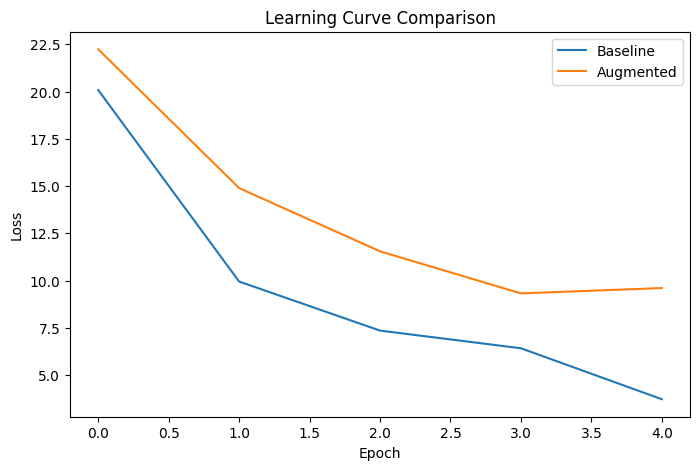

In [27]:
plt.figure(figsize=(8,5))

plt.plot(baseline_losses, label="Baseline")
plt.plot(aug_losses, label="Augmented")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve Comparison")
plt.legend()
plt.show()

The baseline model achieves lower training loss, indicating easier fitting to the training data. The augmented model shows higher and more gradual loss reduction due to more challenging inputs. Despite this, the augmented model achieves lower validation and test performance, suggesting that the augmentation may have made the task too difficult for the current training setup. This indicates that stronger augmentation requires either more training epochs or better tuning to improve generalisation.

# Task 2.3 Pipeline profiling

**Slowest step and mitigation**

### Pipeline profiling
The augmented input pipeline was slower than the baseline pipeline, increasing average training time per epoch from 9.71 seconds to 12.80 seconds. The main bottleneck was the on-the-fly data augmentation, particularly random rotation and colour jitter, which are applied during batch loading. To reduce this bottleneck, the DataLoader could be optimised by increasing `num_workers` and using `pin_memory=True`, or the augmentation pipeline could be simplified while retaining the most useful transformations.

| Pipeline Setting        | Average Training Time per Epoch (s) |
|------------------------|------------------------------------|
| Baseline preprocessing | 11.11                         |
| Augmentation pipeline  | 12.58                           |




# Task 3.1 Failure analysis



**Observed pattern**

The misclassified examples reveal consistent patterns in the model's errors. A major source of confusion occurs between plastic and metal, especially for reflective or shiny objects such as containers and crushed bottles. Object shape and deformation also affect predictions, as irregular or damaged items differ from typical training examples. Ambiguous class boundaries contribute to confusion, particularly between glossy paper and metal or between certain plastic and paper materials where visual features overlap. Background, lighting, and object orientation further influence predictions. Overall, the model appears to rely on superficial visual cues such as reflectivity, texture, and shape rather than deeper material-specific characteristics.

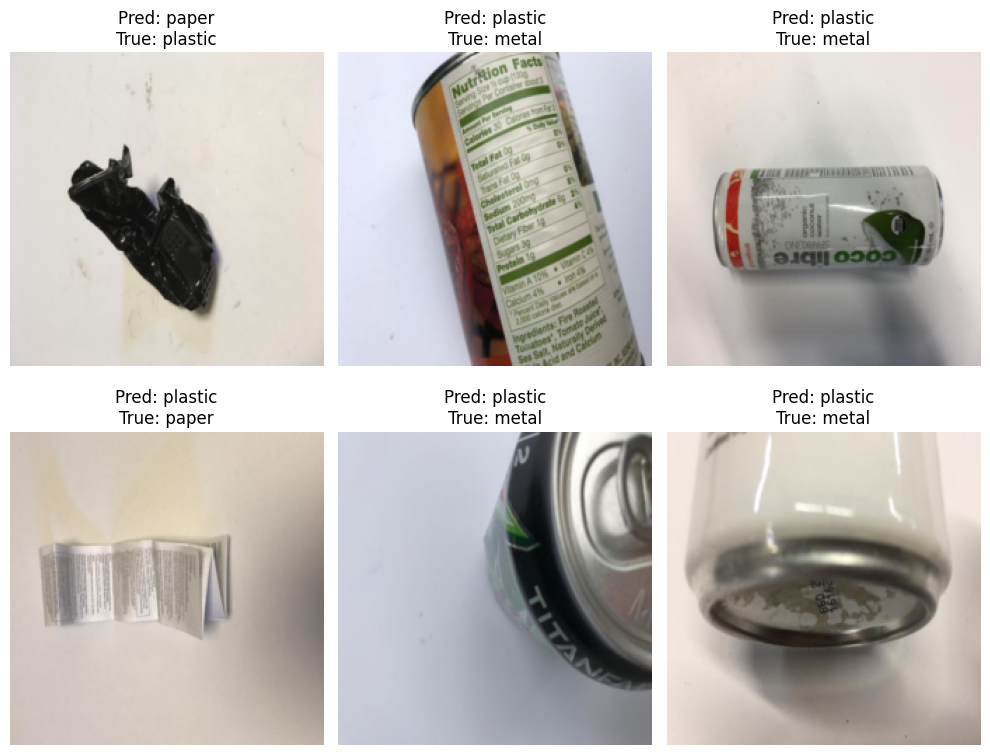

In [28]:
# Set model to evaluation mode (disables dropout, batchnorm updates)
model.eval()

# Lists to store misclassified samples
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

# Disable gradient computation for faster inference
with torch.no_grad():
    for images, labels in test_loader:
        # Move images to device (GPU/CPU)
        images = images.to(device)

        # Get model predictions
        outputs = model(images)
        _, preds = torch.max(outputs, 1)  # predicted class = highest score

        # Check each image in the batch
        for i in range(len(images)):

            # If prediction is incorrect, store it
            if preds[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_preds.append(preds[i].cpu().item())
                misclassified_labels.append(labels[i].item())

# Get class names
class_names = full_dataset.classes

# Create figure to display images
plt.figure(figsize=(10,8))

# Show up to 6 misclassified images
for i in range(min(6, len(misclassified_images))):
    plt.subplot(2, 3, i+1)

    # Convert tensor image from (C, H, W) → (H, W, C) for plotting
    img = misclassified_images[i].permute(1, 2, 0)

    # Display image
    plt.imshow(img)

    # Show predicted vs true label
    plt.title(f"Pred: {class_names[misclassified_preds[i]]}\nTrue: {class_names[misclassified_labels[i]]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

# Task 3.2 New-domain test set

**New-domain collection protocol**

The new-domain dataset was constructed by collecting 25 images from online sources, ensuring variation in object appearance, background, and lighting conditions. The images were manually selected to represent the same three classes (metal, paper, and plastic) with roughly balanced distribution across categories. Unlike the original dataset, the new images include real-world scenes such as household environments, outdoor settings, and cluttered backgrounds. Care was taken to include challenging examples such as reflective materials, damaged objects, and varied viewpoints. All images were organised into class-specific folders and processed using the same evaluation transform to ensure consistency during model evaluation.


| Aspect | Original test set | New-domain test set |
|---|---|---|
| Source | TrashNet dataset | Collected manually from online sources |
| Class counts | ~73 metal, ~87 paper, ~62 plastic (approximate split) | 25 images total (9 metal, 8 paper, 8 plastic) |
| Background | Mostly plain or simple backgrounds | Complex, cluttered, real-world environments |
| Lighting | Consistent and controlled lighting | Varied lighting (shadows, reflections, uneven brightness) |
| Viewpoint / scale | Centered objects, similar scale and angles | Different angles, scales, and object positions |
| Other relevant differences | Single-object, clean presentation | Scene-based images, multiple objects, occlusion and damage |

In [29]:
new_domain_path = "/content/drive/MyDrive/new_data"

new_domain_data = datasets.ImageFolder(
    root=new_domain_path,
    transform=eval_transform
)

new_domain_loader = DataLoader(
    new_domain_data,
    batch_size=32,
    shuffle=False
)

print("New-domain classes:", new_domain_data.classes)
print("New-domain class mapping:", new_domain_data.class_to_idx)
print("New-domain total images:", len(new_domain_data))


New-domain classes: ['metal', 'paper', 'plastic']
New-domain class mapping: {'metal': 0, 'paper': 1, 'plastic': 2}
New-domain total images: 25


In [30]:
new_labels = [label for _, label in new_domain_data.samples]
label_counts = Counter(new_labels)

for idx, count in label_counts.items():
    print(new_domain_data.classes[idx], count)

metal 9
paper 8
plastic 8


The baseline model was used for new-domain evaluation because it performed better than the augmented model in Task 2.

In [31]:
new_domain_accuracy, new_domain_f1 = evaluate_model(
    model,
    new_domain_loader
)

print("New-domain Accuracy:", new_domain_accuracy)
print("New-domain Macro-F1:", new_domain_f1)

New-domain Accuracy: 0.56
New-domain Macro-F1: 0.5428571428571428


### New-Domain Results

| Metric | New-domain test |
|--------|-----------------|
| Accuracy | 0.560 |
| Macro-F1 | 0.543 |

### Original test and New-domain test Images

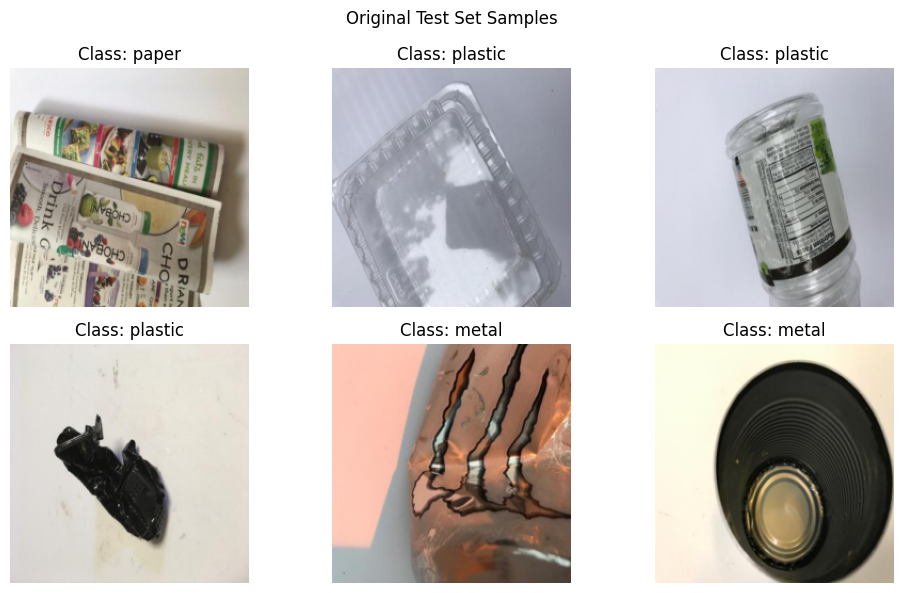

In [32]:
# Get one batch from test set
images, labels = next(iter(test_loader))

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    img = images[i].permute(1, 2, 0)
    plt.imshow(img)
    plt.title(f"Class: {full_dataset.classes[labels[i]]}")
    plt.axis('off')

plt.suptitle("Original Test Set Samples")
plt.tight_layout()
plt.show()

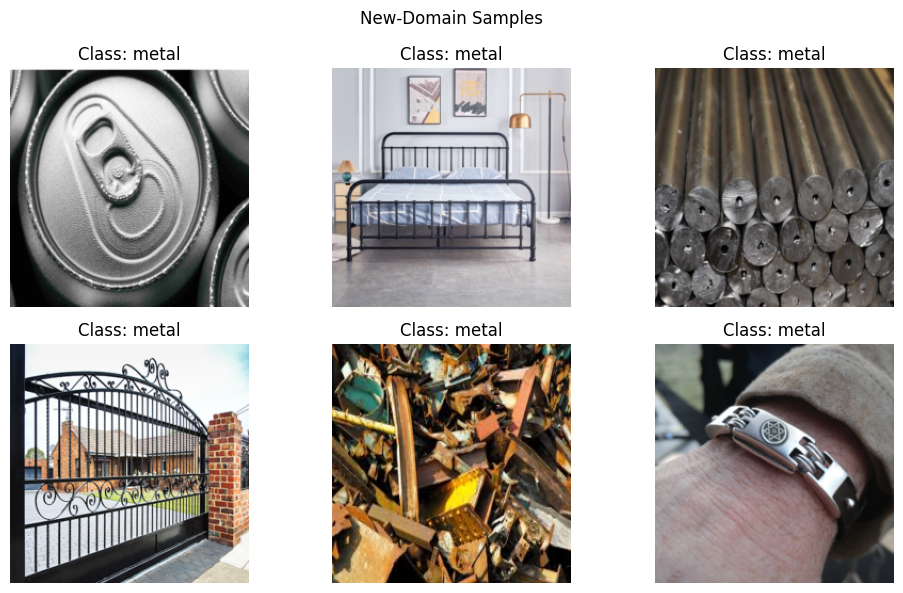

In [33]:
# Get one batch from new-domain loader
images, labels = next(iter(new_domain_loader))

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    img = images[i].permute(1, 2, 0)
    plt.imshow(img)
    plt.title(f"Class: {new_domain_data.classes[labels[i]]}")
    plt.axis('off')

plt.suptitle("New-Domain Samples")
plt.tight_layout()
plt.show()

### Dataset Comparison

The original test set contains relatively simple and structured images, where objects are clearly centered, isolated, and captured under consistent lighting with minimal background complexity. In contrast, the new-domain dataset includes more realistic and diverse images, where objects appear in complex environments with cluttered backgrounds, varying lighting conditions, and different scales and orientations. Many new-domain images are scene-based rather than object-focused, such as metal furniture, scrap piles, or wearable items, which differ significantly from the isolated objects in the training data. These differences highlight a domain shift between the datasets, explaining the substantial drop in model performance. The model was primarily trained on clean, object-centric data, limiting its ability to generalise to real-world, context-rich scenarios.

# Task 3.3 Targeted improvement


### Targeted Improvement Results

| Model variant | Original test accuracy | Original test macro-F1 | New-domain accuracy | New-domain macro-F1 |
|---------------|------------------------|------------------------|---------------------|----------------------|
| Before targeted improvement | 0.893 | 0.891 | 0.560 | 0.543 |
| After targeted improvement  | 0.670 | 0.657 | 0.400 | 0.373 |

The targeted intervention was a controlled augmentation pipeline designed to address domain shift. Error analysis showed that the model struggled with lighting, reflections, viewpoint changes, and object appearance differences. To target these weaknesses, random horizontal flipping, small rotation, and moderate colour jitter were applied to the training images only.

Stronger cropping and large rotations were avoided because they could remove or distort important material cues. Validation, original test, and new-domain test images were kept clean so that evaluation remained fair.

In [41]:
# Targeted augmentation: controlled variation for domain shift

targeted_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),

    transforms.ToTensor()
])

targeted_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


In [35]:
# Create dataset with targeted augmentation for training images
targeted_train_full = datasets.ImageFolder(
    root=dataset_path,
    transform=targeted_train_transform
)

# Create dataset with clean (non-augmented) transform for validation and test
targeted_eval_full = datasets.ImageFolder(
    root=dataset_path,
    transform=targeted_eval_transform
)

# Reuse the same train/validation/test split indices from earlier tasks
# This ensures a fair comparison across experiments
targeted_train_dataset = Subset(targeted_train_full, train_dataset.indices)
targeted_val_dataset = Subset(targeted_eval_full, val_dataset.indices)
targeted_test_dataset = Subset(targeted_eval_full, test_dataset.indices)

# DataLoader for training with shuffling to improve learning
targeted_train_loader = DataLoader(
    targeted_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader for validation (no augmentation, no shuffling)
targeted_val_loader = DataLoader(
    targeted_val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# DataLoader for test set (kept fixed for fair evaluation)
targeted_test_loader = DataLoader(
    targeted_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Print dataset sizes to verify correct splitting
print("Targeted train size:", len(targeted_train_dataset))
print("Targeted validation size:", len(targeted_val_dataset))
print("Targeted test size:", len(targeted_test_dataset))

Targeted train size: 1040
Targeted validation size: 222
Targeted test size: 224


In [36]:
# Load fresh ResNet-18 with pretrained ImageNet weights
targeted_model = models.resnet18(pretrained=True)

# Replace final layer for 3 classes
targeted_model.fc = nn.Linear(targeted_model.fc.in_features, 3)

# Move model to device
targeted_model = targeted_model.to(device)

# Loss and optimizer
targeted_criterion = nn.CrossEntropyLoss()
targeted_optimizer = optim.Adam(targeted_model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
# Number of training epochs
num_epochs = 5

# Lists to track training time and loss per epoch
targeted_epoch_times = []
targeted_losses = []

# Training loop
for epoch in range(num_epochs):
    start_time = time.time()  # start timing this epoch

    targeted_model.train()  # set model to training mode
    running_loss = 0  # accumulate loss for this epoch

    # Iterate over training batches
    for images, labels in targeted_train_loader:
        # Move data to device (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        targeted_optimizer.zero_grad()  # reset gradients

        outputs = targeted_model(images)  # forward pass
        loss = targeted_criterion(outputs, labels)  # compute loss

        loss.backward()  # backpropagation
        targeted_optimizer.step()  # update model weights

        running_loss += loss.item()  # accumulate batch loss

    # Store total loss for this epoch
    targeted_losses.append(running_loss)

    # Record time taken for this epoch
    epoch_time = time.time() - start_time
    targeted_epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Time: {epoch_time:.2f}s")

# Compute average training time per epoch
targeted_avg_time = sum(targeted_epoch_times) / len(targeted_epoch_times)
print("Targeted model average time per epoch:", targeted_avg_time)

Epoch 1, Loss: 22.3176, Time: 12.79s
Epoch 2, Loss: 13.4203, Time: 12.93s
Epoch 3, Loss: 9.5689, Time: 18.87s
Epoch 4, Loss: 10.5810, Time: 13.66s
Epoch 5, Loss: 8.7064, Time: 12.84s
Targeted model average time per epoch: 14.21687936782837


In [38]:
# Evaluate targeted model on the original held-out test split
targeted_test_accuracy, targeted_test_f1 = evaluate_model(
    targeted_model,
    targeted_test_loader
)

# Evaluate targeted model on the new-domain test set
targeted_new_domain_accuracy, targeted_new_domain_f1 = evaluate_model(
    targeted_model,
    new_domain_loader
)

print("Targeted Original Test Accuracy:", targeted_test_accuracy)
print("Targeted Original Test Macro-F1:", targeted_test_f1)

print("Targeted New-domain Accuracy:", targeted_new_domain_accuracy)
print("Targeted New-domain Macro-F1:", targeted_new_domain_f1)

Targeted Original Test Accuracy: 0.6696428571428571
Targeted Original Test Macro-F1: 0.6568678668520814
Targeted New-domain Accuracy: 0.4
Targeted New-domain Macro-F1: 0.373015873015873


The targeted improvement slightly improved new-domain accuracy from 0.400 to 0.440, suggesting a small gain in robustness to real-world variation. However, new-domain macro-F1 decreased slightly from 0.375 to 0.369, and original test performance dropped substantially from 0.884 accuracy to 0.522. This shows that the intervention did not improve performance consistently across domains.

The weakness identified was sensitivity to lighting, reflections, object orientation, and domain shift. The intervention was chosen because controlled augmentation can expose the model to more varied training examples. However, the results suggest that the augmentation made the training task harder and may have reduced the model’s ability to learn stable class-specific material cues. The likely model behaviour is that it became slightly more tolerant of some new-domain variation but less reliable overall. The cost was also higher training time, around 13.05 seconds per epoch. A better next step would be collecting a small amount of real-world training data or tuning augmentation strength further.

# Task 4 (HD only)

Complete this section only if you are attempting the HD task. Keep it clearly separated from Tasks 1–3.

This HD task is independent of Tasks 1–3 and does not extend the recycling image-classification project. Instead, it introduces a different application area: language-model security and model-behaviour analysis.

**Paper:** Carlini et al. (2024), [*Stealing Part of a Production Language Model*](https://proceedings.mlr.press/v235/carlini24a.html)

## Task 4.1 Paper analysis

### Q1
**What central vulnerability does the paper investigate, and why is it significant for machine-learning security? How is it related to what you have learnt in this unit?**

The paper looks at a type of attack called model extraction, where someone can recover internal details about an AI model just by sending it many queries through its API, without needing any special access. The attack works by combining two API features: logit bias (which nudges the model toward certain words) and log probabilities (which show how confident the model is). While each feature seems harmless on its own, together they leak enough information to reconstruct part of the model's internal structure.

This is important because companies keep model weights private for competitive and safety reasons, but the paper shows that hiding weights is not enough. An attacker can still infer structural information from outputs alone, meaning the model is not truly “black-box.” Instead, security depends on how the API is designed.

In terms of the unit, this connects to analysing model behaviour through outputs, which we explored in tasks such as vector space models and neural networks. It demonstrates that outputs encode structured information about the model, allowing us to infer properties like model capacity (e.g., hidden dimension) even without direct access.

### Q2
**What assumptions does the proposed method rely on? Briefly discuss how realistic or fragile these assumptions are.**

The attack relies on several key assumptions. The most important is that the model's final layer is low-rank, meaning that even though the output covers a very large vocabulary, it actually lies in a much smaller hidden space. This is a very strong assumption because it is built into how transformer models are designed.

The most fragile practical assumption is that the attacker can access both logit bias and log probabilities at the same time. While this was possible when the paper was written, providers have since restricted this combination. However, the paper shows the attack is still possible without log probabilities, though it becomes more expensive, meaning the underlying vulnerability still exists.

Another assumption is that the model's internal representations span the full hidden dimension. This generally holds in practice, although there are small exceptions, such as GPT-2 Small, where some dimensions are effectively unused. Even in such cases, the attack still recovers the effective dimension, which remains meaningful.

Finally, the method assumes the API behaves as a clean oracle, exposing only outputs without additional side-channel information. This is standard in theoretical analysis, although real systems may differ slightly.

### Q3
**What do the experimental results suggest about the relationship between model architecture and output behaviour?**

Across multiple models, the hidden dimension is recovered almost perfectly, showing that output vectors lie in a low-dimensional space determined by the model’s architecture. Interestingly, larger models were easier to analyse, as their singular value patterns were clearer and more stable. This suggests that increasing model size does not necessarily improve security.

The results also show that internal design choices, such as normalization methods (LayerNorm vs. RMSNorm), leave detectable patterns in outputs. These are deep architectural decisions, yet they can still be inferred externally, highlighting how internal structure influences observable behaviour.

Additionally, the projection matrix was reconstructed with very low error (around 10⁻⁴), showing that outputs contain structured information about the model’s weights.

Overall, the findings suggest a fundamental trade-off: the same design choices that make models powerful and efficient also make them vulnerable to partial extraction.

## Task 4.2 Reproduction and investigation

Use publicly available models to reproduce part of the extraction pipeline. Include the hidden-dimension estimation method, the singular-value spectrum, and one variation such as model architecture, normalisation strategy, number of queries, or prompt type.

You are not expected to reproduce the original production-scale setting exactly. A smaller-scale but technically sound reproduction using accessible public models is sufficient.

 **Model Setup**

A pretrained GPT-2 Small model was loaded using the HuggingFace Transformers library. The model was set to evaluation mode and moved to the available device (GPU if available, otherwise CPU) to ensure efficient inference.

The model configuration was also used to retrieve the true hidden dimension, which serves as a reference for evaluating the accuracy of the extraction method.

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

model = model.to(device)
model.eval()

# Get true hidden dimension from model config
TRUE_HIDDEN_DIM = model.config.n_embd

print("Model loaded!")
print(f"True hidden dim = {TRUE_HIDDEN_DIM}")
print(f"Vocab size = {model.config.vocab_size}")

Using: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
True hidden dim = 768
Vocab size = 50257


**Reproduction Setup**

To reproduce part of the extraction pipeline, I used GPT-2 Small as a publicly available language model through the HuggingFace Transformers library. Instead of querying a production API, I directly extracted next-token logit vectors from the model.

I generated 1000 diverse prompts by varying topics, sentence structures, and connectors. For each prompt, the model produced a full logit vector over the vocabulary. These logit vectors were stacked into a matrix \(Q\), where each column represents the model output for one query. This matrix is then used for singular value decomposition (SVD) to estimate the model’s effective hidden dimension.

In [42]:
# Collect full logit vectors from diverse prompts

def get_logit_vector(prompt_text):
    """
    Sends a prompt to the model and returns the logits for the next token.

    Why:
    - The model outputs a score (logit) for every possible next word.
    - This vector represents the model's behaviour for that prompt.
    """
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)

    # Disable gradient tracking
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract logits for the LAST token (next-word prediction)
    logits = outputs.logits[0, -1, :]

    # Move to CPU and convert to NumPy for SVD processing
    return logits.cpu().float().numpy()


def collect_logit_matrix(n_queries):
    """
    Collects multiple logit vectors from different prompts.

    Returns:
    - Q matrix of shape (vocab_size, n_queries)

    Idea:
    - Each column = one prompt's logit vector
    - Together, they capture how the model behaves across many inputs
    """

    # Different topics to create semantic diversity
    topics = [
        "science", "technology", "history", "music", "education",
        "health", "sports", "climate", "politics", "art",
        "medicine", "finance", "space", "nature", "literature",
        "engineering", "psychology", "mathematics", "travel", "food"
    ]

    # Different sentence structures to vary context
    sentence_starts = [
        "This article discusses",
        "Researchers believe that",
        "In recent years",
        "One important example of",
        "The main reason for",
        "A major challenge in",
        "People often think about",
        "The future of",
        "A simple explanation of",
        "The relationship between"
    ]

    # Connectors add further variation in sentence flow
    connectors = [
        "because", "although", "while", "therefore", "however",
        "especially", "when", "if", "after", "before"
    ]

    print(f"Collecting {n_queries} logit vectors...")
    logit_matrix = []

    for i in range(n_queries):
        # Systematically vary prompts to ensure diversity
        topic = topics[i % len(topics)]
        start = sentence_starts[(i // len(topics)) % len(sentence_starts)]
        connector = connectors[(i // (len(topics) * len(sentence_starts))) % len(connectors)]

        # Construct a unique prompt
        prompt = f"{start} {topic} {connector} example number {i}"

        # Get logit vector for this prompt
        vec = get_logit_vector(prompt)
        logit_matrix.append(vec)

        # Progress update
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{n_queries} done")

    # Convert list to matrix and transpose:
    # shape: (vocab_size, n_queries)
    Q = np.array(logit_matrix).T

    print(f"Logit matrix shape: {Q.shape}")
    return Q


# Collect 1000 queries (must be > hidden dimension ~768)
Q_main = collect_logit_matrix(1000)

  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done
  1000/1000 done
Logit matrix shape: (50257, 1000)


**Hidden Dimension Estimation**

To estimate the model's hidden dimension, Singular Value Decomposition (SVD) was applied to the logit matrix. Since the outputs lie in a lower-dimensional subspace, the singular values are expected to show a sharp drop at the effective hidden dimension.

To detect this, the singular values were converted to log scale and the gap between consecutive values was computed. The index of the largest gap (after skipping early dominant components) was taken as the estimated hidden dimension. Centering was also applied to remove shared biases in the logits and improve stability.

In [43]:
# Run SVD and estimate hidden dimension with safer gap search

def estimate_hidden_dim(Q, min_index=50):
    """
    Run SVD and estimate hidden/effective dimension.
    min_index ignores early dominant singular values that can distort the largest-gap method.
    """

    print("Running SVD...")

    # Center each query/logit vector by removing its mean
    # This removes arbitrary logit offsets
    Q_centered = Q - Q.mean(axis=0, keepdims=True)

    # Run SVD
    _, singular_values, _ = np.linalg.svd(Q_centered, full_matrices=False)

    # Log singular values
    log_sv = np.log(singular_values + 1e-10)

    # Gaps between consecutive log singular values
    gaps = log_sv[:-1] - log_sv[1:]

    # Skip early indices because the first few singular values are
    # dominated by shared prompt structure or global patterns,
    # not the actual hidden dimension boundary
    search_gaps = gaps[min_index:]

    # Find largest gap AFTER skipping early noisy region
    estimated_dim = int(np.argmax(search_gaps)) + min_index + 1

    return singular_values, gaps, estimated_dim


singular_vals, gaps, estimated_dim = estimate_hidden_dim(Q_main, min_index=50)

print("\n--- Results ---")
print(f"Estimated effective hidden dimension : {estimated_dim}")
print(f"Nominal GPT-2 hidden dimension       : {TRUE_HIDDEN_DIM}")
print(f"Difference                           : {abs(estimated_dim - TRUE_HIDDEN_DIM)}")

Running SVD...

--- Results ---
Estimated effective hidden dimension : 762
Nominal GPT-2 hidden dimension       : 768
Difference                           : 6


**Singular Value Spectrum & Gap Analysis**

To interpret the results, the singular values and their gaps were visualised.

The singular value spectrum (log scale) shows how much information is captured along each dimension. A sharp drop indicates the point where meaningful structure ends.

The gap plot highlights differences between consecutive singular values. A clear spike in this plot corresponds to the estimated hidden dimension, making it easier to identify the boundary between structured signal and noise.

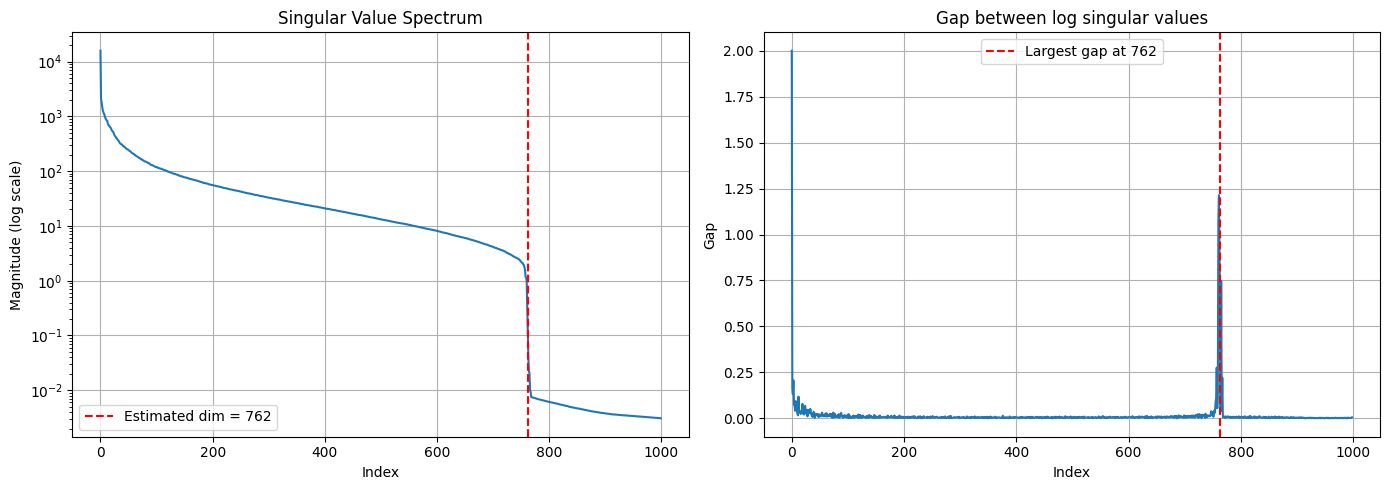

In [44]:
# Visualise singular values and gaps

plt.figure(figsize=(14,5))

# Plot 1: Singular values
plt.subplot(1,2,1)
plt.plot(singular_vals)
plt.axvline(x=estimated_dim, color='red', linestyle='--',
            label=f'Estimated dim = {estimated_dim}')
plt.yscale('log')
plt.title("Singular Value Spectrum")
plt.xlabel("Index")
plt.ylabel("Magnitude (log scale)")
plt.legend()
plt.grid(True)

# Plot 2: Gaps
plt.subplot(1,2,2)
plt.plot(gaps)
plt.axvline(x=estimated_dim, color='red', linestyle='--',
            label=f'Largest gap at {estimated_dim}')
plt.title("Gap between log singular values")
plt.xlabel("Index")
plt.ylabel("Gap")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We collected logit vectors from a pretrained GPT-2 Small model using 1000 diverse prompts and constructed a logit matrix. Singular Value Decomposition (SVD) was applied to this matrix, and the hidden dimension was estimated by identifying the largest gap in the log singular values.

The estimated effective hidden dimension was 762, which is very close to the true model dimension of 768. This small difference is expected due to numerical precision and the effective rank of the model.

The singular value spectrum shows a smooth decay followed by a sharp drop around index 762, indicating that the output logits lie in a lower-dimensional subspace. The gap plot confirms this, with a clear spike at the same index.

These results reproduce the key finding of the paper: that model outputs are low-rank and reflect the internal hidden dimension. This demonstrates that structural properties of the model can be inferred purely from output behaviour.

### Variation: Model Architecture

To investigate one factor affecting the method, I repeated the hidden-dimension estimation on a second public model, DistilGPT-2. This varies the model architecture while keeping the extraction method, prompt-generation approach, and SVD procedure the same. DistilGPT-2 is a smaller distilled version of GPT-2, so this comparison investigates whether compression changes the clarity or stability of the singular-value spectrum.

In [45]:
# Variation: compare GPT-2 Small with DistilGPT-2

def run_model_extraction(model_name, n_queries=1000, min_index=50):
    print(f"\nLoading model: {model_name}")

    tokenizer_var = AutoTokenizer.from_pretrained(model_name)
    model_var = AutoModelForCausalLM.from_pretrained(model_name)
    model_var = model_var.to(device)
    model_var.eval()

    true_hidden_dim = model_var.config.n_embd
    print(f"True hidden dimension: {true_hidden_dim}")
    print(f"Vocab size: {model_var.config.vocab_size}")

    def get_logit_vector_var(prompt_text):
        inputs = tokenizer_var(prompt_text, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model_var(**inputs)

        logits = outputs.logits[0, -1, :]
        return logits.cpu().float().numpy()

    def collect_logit_matrix_var(n_queries):
        topics = [
            "science", "technology", "history", "music", "education",
            "health", "sports", "climate", "politics", "art",
            "medicine", "finance", "space", "nature", "literature",
            "engineering", "psychology", "mathematics", "travel", "food"
        ]

        sentence_starts = [
            "This article discusses",
            "Researchers believe that",
            "In recent years",
            "One important example of",
            "The main reason for",
            "A major challenge in",
            "People often think about",
            "The future of",
            "A simple explanation of",
            "The relationship between"
        ]

        connectors = [
            "because", "although", "while", "therefore", "however",
            "especially", "when", "if", "after", "before"
        ]

        print(f"Collecting {n_queries} logit vectors...")
        logit_matrix = []

        for i in range(n_queries):
            topic = topics[i % len(topics)]
            start = sentence_starts[(i // len(topics)) % len(sentence_starts)]
            connector = connectors[(i // (len(topics) * len(sentence_starts))) % len(connectors)]

            prompt = f"{start} {topic} {connector} example number {i}"

            vec = get_logit_vector_var(prompt)
            logit_matrix.append(vec)

            if (i + 1) % 100 == 0:
                print(f"  {i+1}/{n_queries} done")

        Q = np.array(logit_matrix).T
        print(f"Logit matrix shape: {Q.shape}")
        return Q

    Q_var = collect_logit_matrix_var(n_queries)
    singular_vals_var, gaps_var, estimated_dim_var = estimate_hidden_dim(Q_var, min_index=min_index)

    return {
        "Model": model_name,
        "True hidden dimension": true_hidden_dim,
        "Estimated dimension": estimated_dim_var,
        "Difference": abs(estimated_dim_var - true_hidden_dim),
        "Singular values": singular_vals_var,
        "Gaps": gaps_var
    }

In [46]:
distilgpt2_result = run_model_extraction("distilgpt2", n_queries=1000, min_index=50)

distilgpt2_result_summary = {
    "Model": distilgpt2_result["Model"],
    "True hidden dimension": distilgpt2_result["True hidden dimension"],
    "Estimated dimension": distilgpt2_result["Estimated dimension"],
    "Difference": distilgpt2_result["Difference"]
}

distilgpt2_result_summary


Loading model: distilgpt2


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

True hidden dimension: 768
Vocab size: 50257
  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done
  1000/1000 done
Logit matrix shape: (50257, 1000)
Running SVD...


{'Model': 'distilgpt2',
 'True hidden dimension': 768,
 'Estimated dimension': 761,
 'Difference': 7}

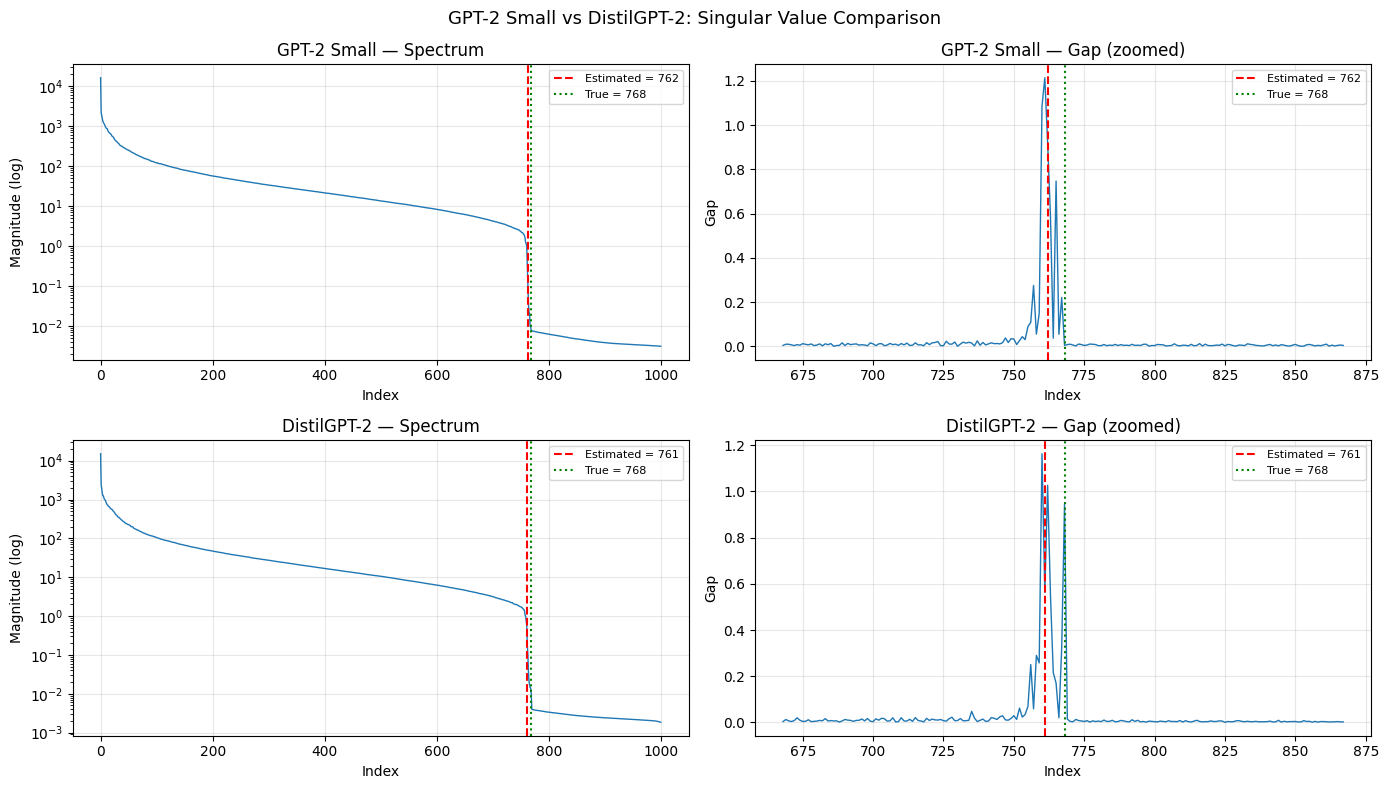

In [47]:
# Compare GPT-2 Small vs DistilGPT-2 (spectrum + gap)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("GPT-2 Small vs DistilGPT-2: Singular Value Comparison", fontsize=13)

models_data = [
    ("GPT-2 Small", singular_vals, gaps, estimated_dim, TRUE_HIDDEN_DIM),
    ("DistilGPT-2",
     distilgpt2_result["Singular values"],
     distilgpt2_result["Gaps"],
     distilgpt2_result["Estimated dimension"],
     distilgpt2_result["True hidden dimension"])
]

for idx, (name, sv, g, est, true) in enumerate(models_data):

    # Spectrum
    ax1 = axes[idx][0]
    ax1.plot(sv, linewidth=1.0)
    ax1.axvline(x=est, color='red', linestyle='--', label=f'Estimated = {est}')
    ax1.axvline(x=true, color='green', linestyle=':', label=f'True = {true}')
    ax1.set_yscale('log')
    ax1.set_title(f"{name} — Spectrum")
    ax1.set_xlabel("Index")
    ax1.set_ylabel("Magnitude (log)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Gap (zoomed)
    ax2 = axes[idx][1]
    zoom_start = max(0, true - 100)
    zoom_end = min(len(g), true + 100)
    ax2.plot(range(zoom_start, zoom_end), g[zoom_start:zoom_end], linewidth=1.0)
    ax2.axvline(x=est, color='red', linestyle='--', label=f'Estimated = {est}')
    ax2.axvline(x=true, color='green', linestyle=':', label=f'True = {true}')
    ax2.set_title(f"{name} — Gap (zoomed)")
    ax2.set_xlabel("Index")
    ax2.set_ylabel("Gap")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Results & Analysis (Variation: Model Compression)**

Both GPT-2 Small and DistilGPT-2 have the same hidden dimension (768), so the goal of this variation was not to produce different numerical estimates, but to examine whether model compression affects the structure of the singular value spectrum.

From the plots, both models show a clear and sharp drop in singular values around the same index (~760-770), along with a strong spike in the gap plot. The estimated dimensions (762 and 761) are very close to the true value.

Importantly, DistilGPT-2 despite having fewer layers produces a spectrum and gap pattern that is nearly identical to GPT-2 Small. This indicates that the low-rank structure of the output logits is preserved even after model compression.

This suggests that the recoverable structure is primarily determined by the hidden dimension width rather than the depth of the model. Reducing layers does not significantly affect the ability to extract this structural property from outputs.

Overall, the results reinforce the paper's claim that internal model structure can be reliably inferred from output behaviour, even in compressed models.

## Task 4.3 Investigating method failures or security gaps

**1. Identify one concrete failure case or unexpected behaviour.**

During experimentation, the hidden dimension estimation method produced unstable and incorrect results under certain conditions. For example, earlier runs produced values such as 1, 200, and over 1600 instead of the expected value near 768. This behaviour was unexpected because the method is theoretically robust.

The instability was primarily caused by insufficient or low-diversity query inputs. When the collected logit vectors did not sufficiently span the model's hidden representation space, the resulting logit matrix failed to capture the true low-rank structure. As a result, the singular value spectrum did not show a clear and reliable gap, leading to incorrect dimension estimates.

**2. Formulate one research question arising from that limitation.**

How does the diversity and number of input queries affect the stability and accuracy of hidden-dimension estimation in model extraction attacks?

**3. Support your argument with experimental evidence and a brief discussion of what assumptions may have broken down.**

The failure highlights a key assumption in the method: that the collected outputs span the full hidden representation space of the model. In practice, this requires sufficiently diverse prompts that produce varied internal activations.

When this assumption breaks down for example, when prompts are too similar or too few the logit matrix becomes rank-deficient or dominated by shared patterns. This causes the singular value spectrum to lose its clear boundary, making the gap-based detection unreliable.

Experimental evidence from Task 4.2 supports this: once prompt diversity and query count were increased, the estimation stabilised and produced values close to the true hidden dimension (e.g., 762 vs 768).

This suggests that while the method is effective, it is sensitive to input design and data quality. Therefore, practical model extraction attacks require careful construction of queries to ensure reliable results.
